# UPI Transaction Analysis with Python (Beginner-Friendly)

**Dataset:** 1,000 UPI transactions (4 Jun - 3 Jul 2024)

## How to use this notebook (explained like you're 5)
A Jupyter notebook is like a **school notebook** made of little boxes called **cells**.

- 📝 **Text cell** (like this one): only for reading. It explains things.
- 💻 **Code cell** (grey box with `In [ ]`): you write Python instructions in it.
- ▶️ **Run a cell:** click inside it and press **Shift + Enter**. Python does what the box says and shows the answer right below.
- Run cells **from top to bottom**. Each cell remembers what earlier cells did.
- Something broke? Menu **Kernel → Restart & Run All** starts fresh.

**Setup (one time):** open Command Prompt / Terminal and type:
```
pip install pandas matplotlib notebook
jupyter notebook
```
A browser tab opens. Click **New → Python 3**, or upload this file. Keep `transaction_dataset.csv` in the **same folder** as this notebook.

## Step 0: Bring in the tools
**pandas** = Excel on steroids (tables are called *DataFrames*).
**matplotlib** = draws charts.
`import ... as pd` just gives it a short nickname.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Tools loaded!")

Tools loaded!


## Step 1: Open the file and peek inside
`pd.read_csv()` = "open this CSV file". `df` is our table (short for DataFrame).
`df.head()` shows the first 5 rows, like peeking at the first page.

In [2]:
df = pd.read_csv("transaction_dataset.csv")
df.head()

,Transaction ID,Timestamp,Sender Name,Sender UPI ID,Receiver Name,Receiver UPI ID,Amount (INR),Status
0,4d3db980-46cd-4158-a812-dcb77055d0d2,2024-06-22 04:06:38,Tiya Mall,4161803452@okaxis,Mohanlal Golla,7776849307@okybl,3907.34,FAILED
1,099ee548-2fc1-4811-bf92-559c467ca792,2024-06-19 06:04:49,Mohanlal Bakshi,8908837379@okaxis,Mehul Sankaran,7683454560@okaxis,8404.55,SUCCESS
2,d4c05732-6b1b-4bab-90b9-efe09d252b99,2024-06-04 04:56:09,Kismat Bora,4633654150@okybl,Diya Goel,2598130823@okicici,941.88,SUCCESS
3,e8df92ee-8b04-4133-af5a-5f412180c8ab,2024-06-09 09:56:07,Ayesha Korpal,7018842771@okhdfcbank,Rhea Kothari,2246623650@okaxis,8926.00,SUCCESS
4,e7d675d3-04f1-419c-a841-7a04662560b7,2024-06-25 08:38:19,Jivin Batta,1977143985@okybl,Baiju Issac,5245672729@okybl,2800.55,SUCCESS


In [3]:
# How big is the table? (rows, columns)
print(df.shape)

# What type of data is in each column? Any empty cells?
df.info()

(1000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction ID   1000 non-null   str    
 1   Timestamp        1000 non-null   str    
 2   Sender Name      1000 non-null   str    
 3   Sender UPI ID    1000 non-null   str    
 4   Receiver Name    1000 non-null   str    
 5   Receiver UPI ID  1000 non-null   str    
 6   Amount (INR)     1000 non-null   float64
 7   Status           1000 non-null   str    
dtypes: float64(1), str(7)
memory usage: 62.6 KB


## Step 2: Clean up (tidy the room before playing)
1. Give columns simple names (no spaces, all lowercase), because it's easier to type.
2. Turn the `timestamp` text into a real date-time so Python understands dates.
3. Check for empty cells and duplicates.

In [4]:
df.columns = ["transaction_id", "timestamp", "sender_name", "sender_upi_id",
              "receiver_name", "receiver_upi_id", "amount_inr", "status"]

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Empty cells per column:")
print(df.isnull().sum())
print()
print("Duplicate transaction IDs:", df["transaction_id"].duplicated().sum())

Empty cells per column:
transaction_id     0
timestamp          0
sender_name        0
sender_upi_id      0
receiver_name      0
receiver_upi_id    0
amount_inr         0
status             0
dtype: int64

Duplicate transaction IDs: 0


## Step 3: Make helpful new columns (feature engineering)
Think of it as writing extra labels on every row so grouping is easy later:
- `hour`, `day_name`, `date` come from the timestamp
- `sender_bank` = the text after `@` in the UPI ID
- `is_failed` = 1 if FAILED, else 0 (so the **average** of this column = failure rate!)

In [5]:
df["hour"]      = df["timestamp"].dt.hour
df["day_name"]  = df["timestamp"].dt.day_name()
df["date"]      = df["timestamp"].dt.date

df["sender_bank"]   = df["sender_upi_id"].str.split("@").str[1]
df["receiver_bank"] = df["receiver_upi_id"].str.split("@").str[1]

df["is_failed"] = (df["status"] == "FAILED").astype(int)

# Amount buckets (like CASE WHEN in SQL)
df["amount_bucket"] = pd.cut(
    df["amount_inr"],
    bins=[0, 2500, 5000, 7500, float("inf")],
    labels=["0-2,500", "2,500-5,000", "5,000-7,500", "7,500+"]
)

df.head()

,transaction_id,timestamp,sender_name,sender_upi_id,receiver_name,receiver_upi_id,amount_inr,status,hour,day_name,date,sender_bank,receiver_bank,is_failed,amount_bucket
0,4d3db980-46cd-4158-a812-dcb77055d0d2,2024-06-22 04:06:38,Tiya Mall,4161803452@okaxis,Mohanlal Golla,7776849307@okybl,3907.34,FAILED,4,Saturday,2024-06-22,okaxis,okybl,1,"2,500-5,000"
1,099ee548-2fc1-4811-bf92-559c467ca792,2024-06-19 06:04:49,Mohanlal Bakshi,8908837379@okaxis,Mehul Sankaran,7683454560@okaxis,8404.55,SUCCESS,6,Wednesday,2024-06-19,okaxis,okaxis,0,"7,500+"
2,d4c05732-6b1b-4bab-90b9-efe09d252b99,2024-06-04 04:56:09,Kismat Bora,4633654150@okybl,Diya Goel,2598130823@okicici,941.88,SUCCESS,4,Tuesday,2024-06-04,okybl,okicici,0,"0-2,500"
3,e8df92ee-8b04-4133-af5a-5f412180c8ab,2024-06-09 09:56:07,Ayesha Korpal,7018842771@okhdfcbank,Rhea Kothari,2246623650@okaxis,8926.00,SUCCESS,9,Sunday,2024-06-09,okhdfcbank,okaxis,0,"7,500+"
4,e7d675d3-04f1-419c-a841-7a04662560b7,2024-06-25 08:38:19,Jivin Batta,1977143985@okybl,Baiju Issac,5245672729@okybl,2800.55,SUCCESS,8,Tuesday,2024-06-25,okybl,okybl,0,"2,500-5,000"


## 🔑 The 3 magic moves you'll use again and again
| Move | Meaning | SQL twin |
|---|---|---|
| `df[df["status"] == "SUCCESS"]` | keep only some rows | `WHERE` |
| `df.groupby("col")` | make piles by a column | `GROUP BY` |
| `.agg(...)` / `.sum()` / `.mean()` | calculate for each pile | `SUM()`, `AVG()` |

Now the 10 business questions!

## Q1. How reliable is our payment system?
**Plan:** count all rows, count FAILED rows, divide. Add up the money in failed payments.

In [6]:
total_txns   = len(df)
failed_txns  = df["is_failed"].sum()
failure_rate = df["is_failed"].mean() * 100
failed_money = df.loc[df["status"] == "FAILED", "amount_inr"].sum()

print(f"Total transactions : {total_txns}")
print(f"Failed transactions: {failed_txns}")
print(f"Failure rate       : {failure_rate:.2f}%")
print(f"Money stuck in failed payments: ₹{failed_money:,.2f}")

Total transactions : 1000
Failed transactions: 498
Failure rate       : 49.80%
Money stuck in failed payments: ₹2,459,465.24


**💡 Insight:** Nearly 1 in 2 payments fails (≈49.8%), and about ₹24.6 lakh was stuck in failed payments. That's a serious reliability problem.

## Q2. Which sender bank causes the most failures?
**Plan:** make one pile per bank, then find the average of `is_failed` in each pile.

In [7]:
bank_fail = (df.groupby("sender_bank")
               .agg(total_txns=("transaction_id", "count"),
                    failed_txns=("is_failed", "sum"),
                    failure_rate_pct=("is_failed", lambda x: round(x.mean() * 100, 2)))
               .sort_values("failure_rate_pct", ascending=False))
bank_fail

,total_txns,failed_txns,failure_rate_pct
sender_bank,,,
okaxis,198,107,54.04
okhdfcbank,188,99,52.66
okybl,199,97,48.74
okicici,206,97,47.09
oksbi,209,98,46.89


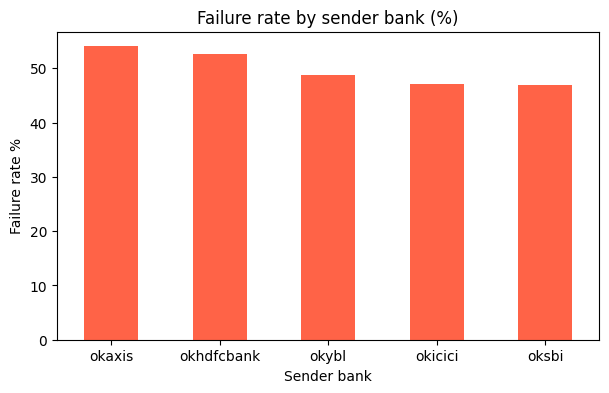

In [8]:
bank_fail["failure_rate_pct"].plot(kind="bar", color="tomato", figsize=(7, 4))
plt.title("Failure rate by sender bank (%)")
plt.ylabel("Failure rate %")
plt.xlabel("Sender bank")
plt.xticks(rotation=0)
plt.show()

**💡 Insight:** `okaxis` has the highest failure rate (≈54%), then `okhdfcbank`. Banks are fairly close, so no single bank is solely to blame.

## Q3. When do people pay the most? (hour and weekday)

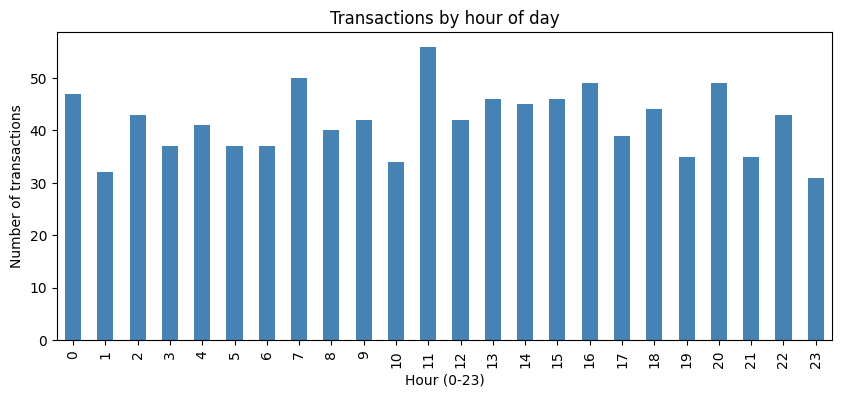

Busiest hours:
hour
11    56
7     50
16    49
Name: transaction_id, dtype: int64


In [9]:
by_hour = df.groupby("hour")["transaction_id"].count()
by_hour.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Transactions by hour of day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Number of transactions")
plt.show()

print("Busiest hours:")
print(by_hour.sort_values(ascending=False).head(3))

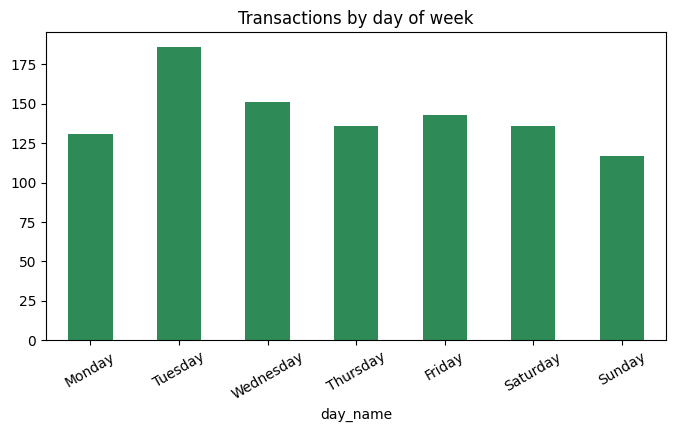

,total_txns
day_name,
Monday,131
Tuesday,186
Wednesday,151
Thursday,136
Friday,143
Saturday,136
Sunday,117


In [10]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = (df.groupby("day_name")
            .agg(total_txns=("transaction_id", "count"))
            .reindex(order))
by_day.plot(kind="bar", legend=False, figsize=(8, 4), color="seagreen")
plt.title("Transactions by day of week")
plt.xticks(rotation=30)
plt.show()

by_day

**💡 Insight:** Hour 11 is the busiest, followed by 7 and 20. Tuesday has the highest volume of the week. (In a 30-day sample, weekday volume can be affected by how many of each weekday fall in the period.)

## Q4. When do payments fail the most?
Same idea as Q2 but piles are **hours**.

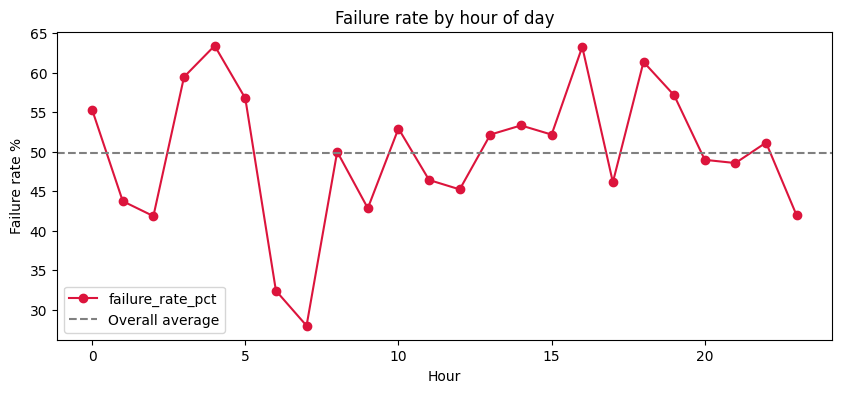

,total_txns,failure_rate_pct
hour,,
4,41,63.41
16,49,63.27
18,44,61.36
3,37,59.46
19,35,57.14


In [11]:
hour_fail = (df.groupby("hour")
               .agg(total_txns=("transaction_id", "count"),
                    failure_rate_pct=("is_failed", lambda x: round(x.mean() * 100, 2))))

hour_fail["failure_rate_pct"].plot(kind="line", marker="o", figsize=(10, 4), color="crimson")
plt.axhline(df["is_failed"].mean() * 100, linestyle="--", color="grey", label="Overall average")
plt.title("Failure rate by hour of day")
plt.xlabel("Hour")
plt.ylabel("Failure rate %")
plt.legend()
plt.show()

hour_fail.sort_values("failure_rate_pct", ascending=False).head(5)

**💡 Insight:** Failure rates swing by hour (for example, hour 4 and hour 16 are above 63%). Check whether hours with few transactions are just noisy before drawing conclusions.

## Q5. Does the amount affect failure?

In [12]:
bucket_fail = (df.groupby("amount_bucket", observed=True)
                 .agg(total_txns=("transaction_id", "count"),
                      failed_txns=("is_failed", "sum"),
                      failure_rate_pct=("is_failed", lambda x: round(x.mean() * 100, 2))))
bucket_fail

,total_txns,failed_txns,failure_rate_pct
amount_bucket,,,
"0-2,500",249,129,51.81
"2,500-5,000",262,123,46.95
"5,000-7,500",253,128,50.59
"7,500+",236,118,50.00


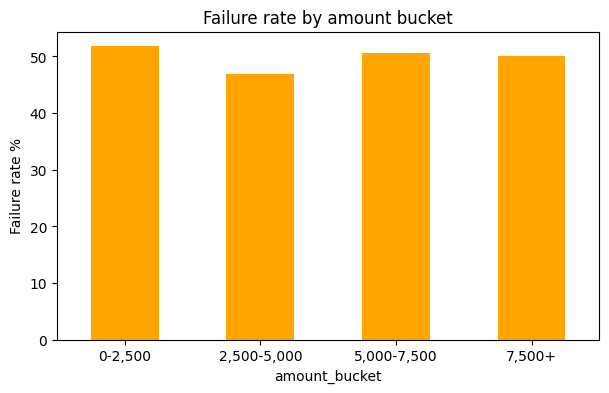

In [13]:
bucket_fail["failure_rate_pct"].plot(kind="bar", color="orange", figsize=(7, 4))
plt.title("Failure rate by amount bucket")
plt.ylabel("Failure rate %")
plt.xticks(rotation=0)
plt.show()

**💡 Insight:** Failure rates are about the same in every amount bucket (roughly 47-52%), so the amount does **not** noticeably drive failures.

## Q6. How much money actually moved? (successful payments only)

In [14]:
success = df[df["status"] == "SUCCESS"]

print(f"Successful transactions : {len(success)}")
print(f"Total money moved       : ₹{success['amount_inr'].sum():,.2f}")
print(f"Average ticket size     : ₹{success['amount_inr'].mean():,.2f}")
print(f"Smallest payment        : ₹{success['amount_inr'].min():,.2f}")
print(f"Largest payment         : ₹{success['amount_inr'].max():,.2f}")

Successful transactions : 502
Total money moved       : ₹2,539,557.69
Average ticket size     : ₹5,058.88
Smallest payment        : ₹53.13
Largest payment         : ₹9,993.06


**💡 Insight:** ₹25.4 lakh moved successfully with an average ticket of about ₹5,059.

## Q7. Which banks do money flow between?
Group by **two** columns at once: sender bank and receiver bank.

In [15]:
flow = (df.groupby(["sender_bank", "receiver_bank"])
          .agg(total_txns=("transaction_id", "count"),
               success_amount=("amount_inr", lambda x: x[df.loc[x.index, "status"] == "SUCCESS"].sum()),
               success_rate_pct=("is_failed", lambda x: round((1 - x.mean()) * 100, 2)))
          .sort_values("total_txns", ascending=False)
          .head(10))
flow

total_txns  success_amount  success_rate_pct
sender_bank receiver_bank                                              
okybl       okhdfcbank             56       115862.57             37.50
okicici     okicici                49       136790.10             51.02
            okybl                  45       112634.29             53.33
oksbi       okaxis                 44       131527.33             52.27
            oksbi                  44       140867.19             63.64
            okhdfcbank             44        77630.49             47.73
okaxis      okaxis                 44       132567.82             52.27
okhdfcbank  okicici                42       125178.26             57.14
okicici     oksbi                  42       115351.88             50.00
okhdfcbank  okybl                  41        96633.81             53.66

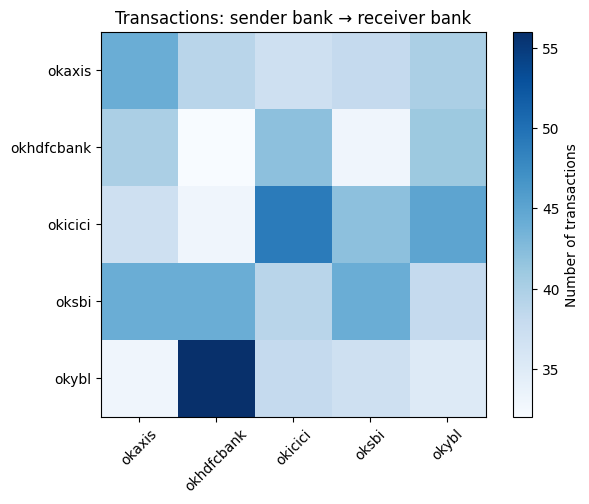

In [16]:
# A heatmap-style table: rows = sender bank, columns = receiver bank
pivot = df.pivot_table(index="sender_bank", columns="receiver_bank",
                       values="transaction_id", aggfunc="count")

plt.figure(figsize=(7, 5))
plt.imshow(pivot, cmap="Blues")
plt.colorbar(label="Number of transactions")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Transactions: sender bank → receiver bank")
plt.show()

**💡 Insight:** The busiest bank-to-bank route is `okybl → okhdfcbank` (56 transactions), but its success rate (37.5%) is well below average. This route deserves a closer look.

## Q8. Who are the repeat users?
`value_counts()` = count how many times each name appears.

In [17]:
repeat = (df.groupby("sender_name")
            .agg(txn_count=("transaction_id", "count"),
                 total_sent=("amount_inr", "sum"))
            .query("txn_count > 1")
            .sort_values(["txn_count", "total_sent"], ascending=False))
repeat

,txn_count,total_sent
sender_name,,
Ivan Ramesh,2,7694.11
Aayush Bakshi,2,7454.10
Prerak Lanka,2,5720.96


**💡 Insight:** Only a few sender names repeat, and every UPI ID is unique. So these are most likely different people with the same name, not repeat customers.

## Q9. Is business growing or flat? (daily trend)

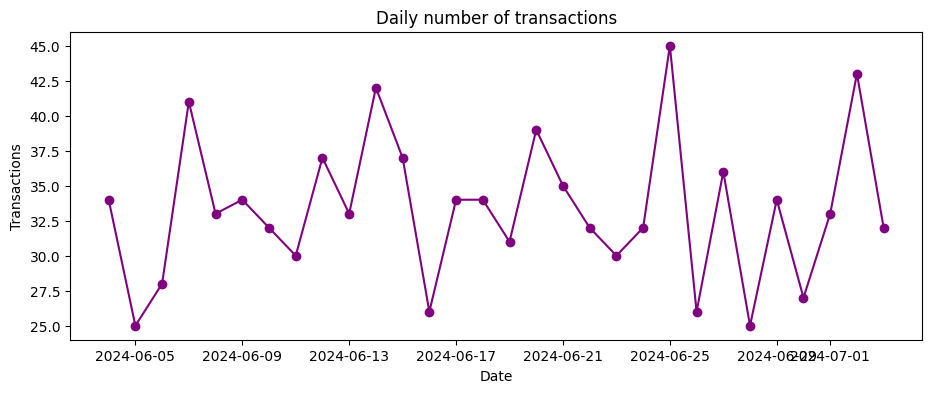

Biggest one-day drop:
2024-06-26 -19.0


,total_txns,success_amount,txn_change_vs_prev_day
date,,,
2024-06-04,34,100809.52,NaN
2024-06-05,25,59394.10,-9.0
2024-06-06,28,49727.56,3.0
2024-06-07,41,85225.71,13.0
2024-06-08,33,99322.51,-8.0


In [18]:
daily = (df.groupby("date")
           .agg(total_txns=("transaction_id", "count"),
                success_amount=("amount_inr", lambda x: x[df.loc[x.index, "status"] == "SUCCESS"].sum())))

daily["txn_change_vs_prev_day"] = daily["total_txns"].diff()

daily["total_txns"].plot(figsize=(11, 4), marker="o", color="purple")
plt.title("Daily number of transactions")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.show()

print("Biggest one-day drop:")
print(daily["txn_change_vs_prev_day"].idxmin(), daily["txn_change_vs_prev_day"].min())
daily.head()

**💡 Insight:** Daily volume bounces between 25 (5 Jun) and 45 (25 Jun) transactions, and the first half and second half of the month both average about 33 per day. Business is flat, not growing. The biggest one-day drop was on 26 Jun (-19 transactions right after the 25 Jun peak).

## Q10. Any suspicious patterns?
Three checks: duplicate IDs, paying yourself, unusually big amounts.

In [19]:
dupes = df["transaction_id"].duplicated().sum()
self_pay = df[(df["sender_upi_id"] == df["receiver_upi_id"]) |
              (df["sender_name"] == df["receiver_name"])]

mean, std = df["amount_inr"].mean(), df["amount_inr"].std()
outliers = df[df["amount_inr"] > mean + 2 * std]

print("Duplicate transaction IDs:", dupes)
print("Self-payments            :", len(self_pay))
print("Unusually large amounts  :", len(outliers))

Duplicate transaction IDs: 0
Self-payments            : 0
Unusually large amounts  : 0


**💡 Insight:** No duplicates, no self-payments and no outliers. The data is clean, which is itself worth mentioning in your portfolio.

---
## 🎉 You did it!
**Cheat sheet to remember**
- `pd.read_csv("file.csv")` → open data
- `df.head()` / `df.info()` → look at data
- `df[df["col"] == "x"]` → filter (WHERE)
- `df.groupby("col").agg(...)` → pile and calculate (GROUP BY)
- `.sort_values(..., ascending=False)` → ORDER BY
- `.plot(kind="bar")` → quick chart

**Next:** save this notebook to your GitHub project with a README that lists your top insights.